In [1]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 615 (delta 13), reused 20 (delta 10), pack-reused 586 (from 1)
Receiving objects: 100% (615/615), 764.37 KiB | 8.05 MiB/s, done.
Resolving deltas: 100% (291/291), done.
/content/NuOscProbExact/src
globaldefs.py  hamiltonians2nu.py  hamiltonians3nu.py  oscprob2nu.py  oscprob3nu.py


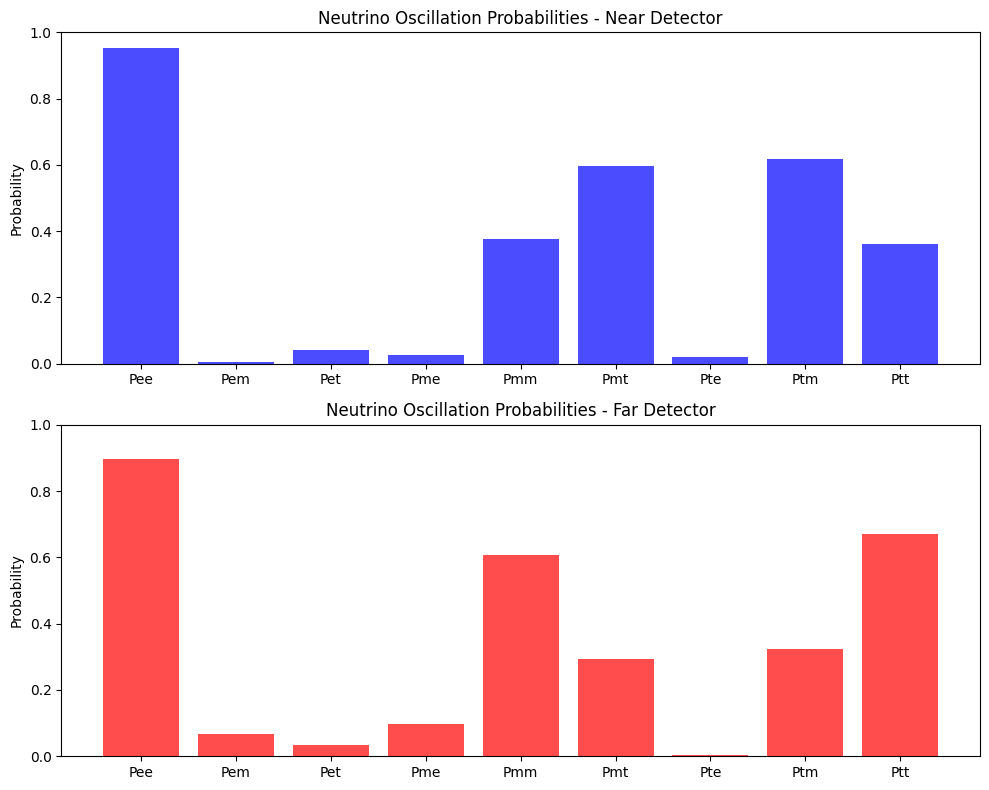

In [2]:
import oscprob3nu
import hamiltonians3nu
from globaldefs import *
import matplotlib.pyplot as plt
import numpy as np

# Function to calculate probabilities for a given baseline
def calculate_probabilities(energy, baseline, VCC):
    h_vacuum_energy_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(S12_NO_BF, S23_NO_BF,
                                                                                      S13_NO_BF, DCP_NO_BF,
                                                                                      D21_NO_BF, D31_NO_BF)
    h_matter = hamiltonians3nu.hamiltonian_3nu_matter(h_vacuum_energy_indep, energy, VCC)
    probabilities = oscprob3nu.probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
    return probabilities

# Neutrino energy [eV]
energy = 1.e9

# Baselines for near and far detectors [km]
baseline_near = 1.3e3
baseline_far = 1.8e3

# Compute probabilities for near detector
probabilities_near = calculate_probabilities(energy, baseline_near, VCC_EARTH_CRUST)
Pee_near, Pem_near, Pet_near, Pme_near, Pmm_near, Pmt_near, Pte_near, Ptm_near, Ptt_near = probabilities_near

# Compute probabilities for far detector
probabilities_far = calculate_probabilities(energy, baseline_far, VCC_EARTH_CRUST)
Pee_far, Pem_far, Pet_far, Pme_far, Pmm_far, Pmt_far, Pte_far, Ptm_far, Ptt_far = probabilities_far

# Labels for each type of probability
labels = ['Pee', 'Pem', 'Pet', 'Pme', 'Pmm', 'Pmt', 'Pte', 'Ptm', 'Ptt']

# Plot histograms
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Near detector histogram
axs[0].bar(labels, [Pee_near, Pem_near, Pet_near, Pme_near, Pmm_near, Pmt_near, Pte_near, Ptm_near, Ptt_near], color='b', alpha=0.7)
axs[0].set_title('Neutrino Oscillation Probabilities - Near Detector')
axs[0].set_ylabel('Probability')
axs[0].set_ylim([0, 1])

# Far detector histogram
axs[1].bar(labels, [Pee_far, Pem_far, Pet_far, Pme_far, Pmm_far, Pmt_far, Pte_far, Ptm_far, Ptt_far], color='r', alpha=0.7)
axs[1].set_title('Neutrino Oscillation Probabilities - Far Detector')
axs[1].set_ylabel('Probability')
axs[1].set_ylim([0, 1])

# Adjust layout and show plot
plt.tight_layout()
plt.show()


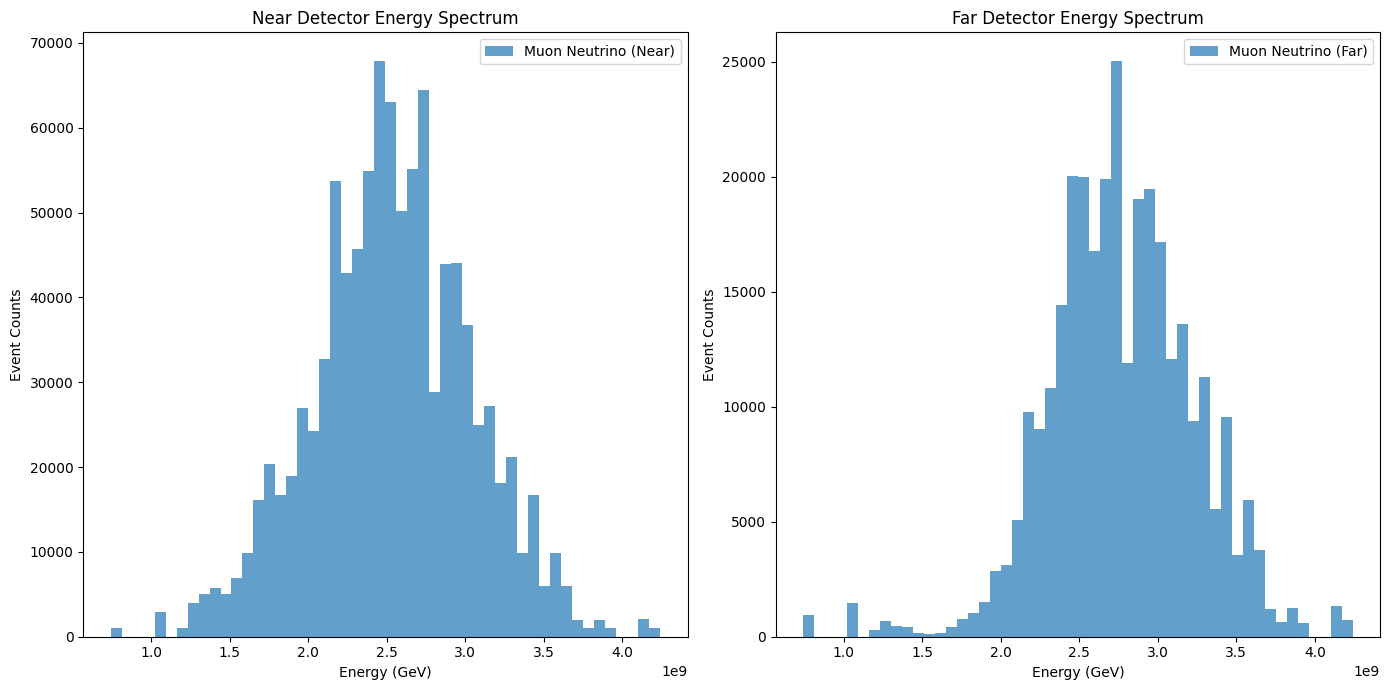

In [5]:
# Import libraries and functions
import numpy as np
import matplotlib.pyplot as plt
import oscprob3nu
import hamiltonians3nu
from globaldefs import *

# Parameters
theta12 = S12_NO_BF
theta23 = S23_NO_BF
theta13 = S13_NO_BF
delta_cp = DCP_NO_BF
mass_squared_difference21 = D21_NO_BF
mass_squared_difference31 = D31_NO_BF
Length_near = 1 * CONV_KM_TO_INV_EV  # Near detector distance in km
Length_far = 800 * CONV_KM_TO_INV_EV  # Far detector distance in km

# Define the Hamiltonian in matter
def hamiltonian_3nu_matter(E):
    h_vacuum_energy_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(theta12, theta23,
                                                                                      theta13, delta_cp,
                                                                                      mass_squared_difference21,
                                                                                      mass_squared_difference31)
    h_matter = hamiltonians3nu.hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
    return h_matter

# Gaussian distribution parameters for energy
mean_energy = 2.5e9  # Mean energy in eV
sigma_energy = 0.5e9  # Standard deviation in eV
energies = np.random.normal(mean_energy, sigma_energy, 1000)

# Function to compute probabilities for a given length
def compute_probabilities(length):
    Prob_e = []
    Prob_mu = []
    Prob_tau = []

    for E in energies:
        h_matter = hamiltonian_3nu_matter(E)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = oscprob3nu.probabilities_3nu(h_matter, length)
        Prob_e.append(Pee)
        Prob_mu.append(Pmm)
        Prob_tau.append(Ptt)

    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute probabilities for near and far detectors
Prob_e_near, Prob_mu_near, Prob_tau_near = compute_probabilities(Length_near)
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities(Length_far)

# Total number of events (near detector has more events than far detector)
total_events_near = 1000
total_events_far = 1000

# Poisson-distributed event counts based on the probability
counts_e_near = np.random.poisson(lam=Prob_e_near * total_events_near)
counts_mu_near = np.random.poisson(lam=Prob_mu_near * total_events_near)
counts_tau_near = np.random.poisson(lam=Prob_tau_near * total_events_near)

counts_e_far = np.random.poisson(lam=Prob_e_far * total_events_far)
counts_mu_far = np.random.poisson(lam=Prob_mu_far * total_events_far)
counts_tau_far = np.random.poisson(lam=Prob_tau_far * total_events_far)

# Plot the histograms
plt.figure(figsize=(14, 7))

# Near detector
plt.subplot(1, 2, 1)
plt.hist(energies, bins=50, weights=counts_mu_near, label='Muon Neutrino (Near)', alpha=0.7)
plt.xlabel('Energy (GeV)')
plt.ylabel('Event Counts')
plt.title('Near Detector Energy Spectrum')
plt.legend()

# Far detector
plt.subplot(1, 2, 2)
plt.hist(energies, bins=50, weights=counts_mu_far, label='Muon Neutrino (Far)', alpha=0.7)
plt.xlabel('Energy (GeV)')
plt.ylabel('Event Counts')
plt.title('Far Detector Energy Spectrum')
plt.legend()

plt.tight_layout()
plt.show()


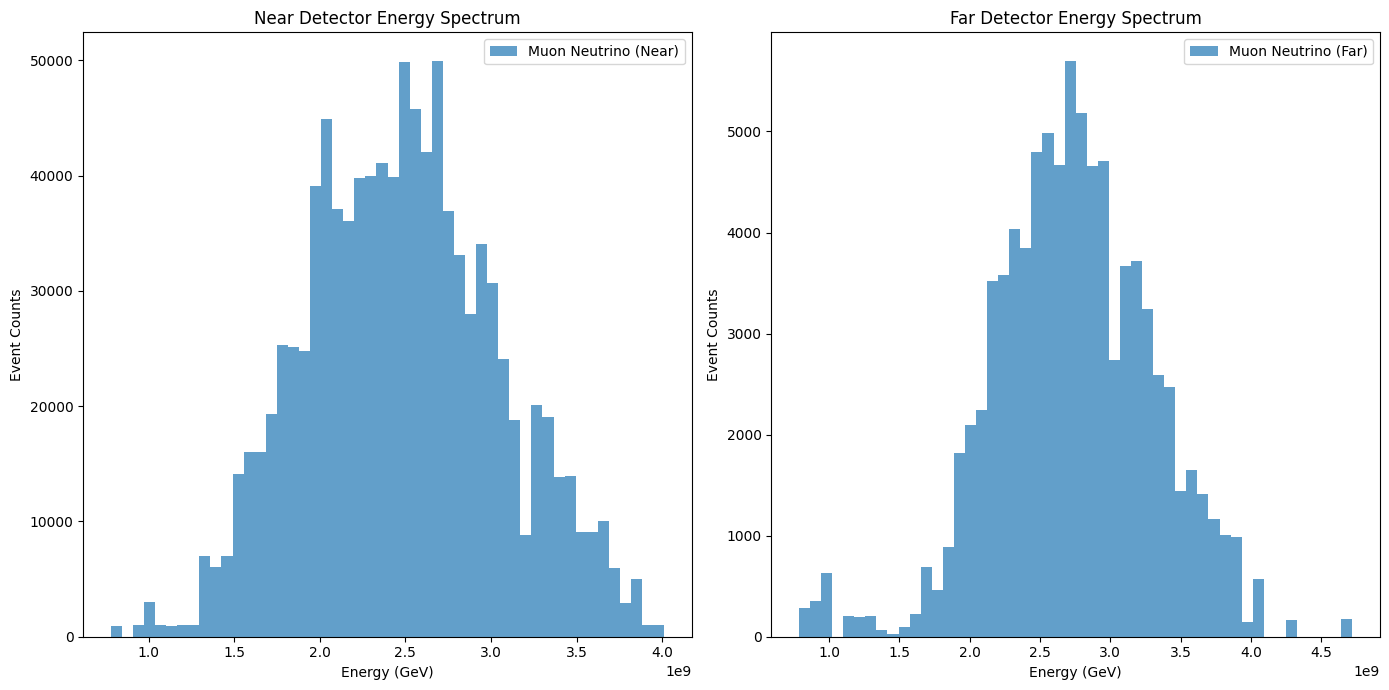

In [6]:
# Import libraries and functions
import numpy as np
import matplotlib.pyplot as plt
import oscprob3nu
import hamiltonians3nu
from globaldefs import *

# Parameters
theta12 = S12_NO_BF
theta23 = S23_NO_BF
theta13 = S13_NO_BF
delta_cp = DCP_NO_BF
mass_squared_difference21 = D21_NO_BF
mass_squared_difference31 = D31_NO_BF
Length_near = 1 * CONV_KM_TO_INV_EV  # Near detector distance in km
Length_far = 810 * CONV_KM_TO_INV_EV  # Far detector distance in km

# Define the Hamiltonian in matter
def hamiltonian_3nu_matter(E):
    h_vacuum_energy_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(theta12, theta23,
                                                                                      theta13, delta_cp,
                                                                                      mass_squared_difference21,
                                                                                      mass_squared_difference31)
    h_matter = hamiltonians3nu.hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
    return h_matter

# Gaussian distribution parameters for energy
mean_energy = 2.5e9  # Mean energy in eV
sigma_energy = 0.5e9  # Standard deviation in eV
energies = np.random.normal(mean_energy, sigma_energy, 1000)

# Function to compute probabilities for a given length
def compute_probabilities(length):
    Prob_e = []
    Prob_mu = []
    Prob_tau = []

    for E in energies:
        h_matter = hamiltonian_3nu_matter(E)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = oscprob3nu.probabilities_3nu(h_matter, length)
        Prob_e.append(Pee)
        Prob_mu.append(Pmm)
        Prob_tau.append(Ptt)

    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute probabilities for near and far detectors
Prob_e_near, Prob_mu_near, Prob_tau_near = compute_probabilities(Length_near)
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities(Length_far)

# Total number of events (near detector has more events than far detector)
total_events_near = 1000
total_events_far = 300

# Poisson-distributed event counts based on the probability, with added background
background_near = 0.1  # Background event rate for near detector
background_far = 0.05  # Background event rate for far detector

counts_e_near = np.random.poisson(lam=Prob_e_near * total_events_near + background_near)
counts_mu_near = np.random.poisson(lam=Prob_mu_near * total_events_near + background_near)
counts_tau_near = np.random.poisson(lam=Prob_tau_near * total_events_near + background_near)

counts_e_far = np.random.poisson(lam=Prob_e_far * total_events_far + background_far)
counts_mu_far = np.random.poisson(lam=Prob_mu_far * total_events_far + background_far)
counts_tau_far = np.random.poisson(lam=Prob_tau_far * total_events_far + background_far)

# Apply detector resolution
energy_resolution = 0.1  # 10% energy resolution
energies_near = energies + np.random.normal(0, energy_resolution * energies, len(energies))
energies_far = energies + np.random.normal(0, energy_resolution * energies, len(energies))

# Plot the histograms
plt.figure(figsize=(14, 7))

# Near detector
plt.subplot(1, 2, 1)
plt.hist(energies_near, bins=50, weights=counts_mu_near, label='Muon Neutrino (Near)', alpha=0.7)
plt.xlabel('Energy (GeV)')
plt.ylabel('Event Counts')
plt.title('Near Detector Energy Spectrum')
plt.legend()

# Far detector
plt.subplot(1, 2, 2)
plt.hist(energies_far, bins=50, weights=counts_mu_far, label='Muon Neutrino (Far)', alpha=0.7)
plt.xlabel('Energy (GeV)')
plt.ylabel('Event Counts')
plt.title('Far Detector Energy Spectrum')
plt.legend()

plt.tight_layout()
plt.show()


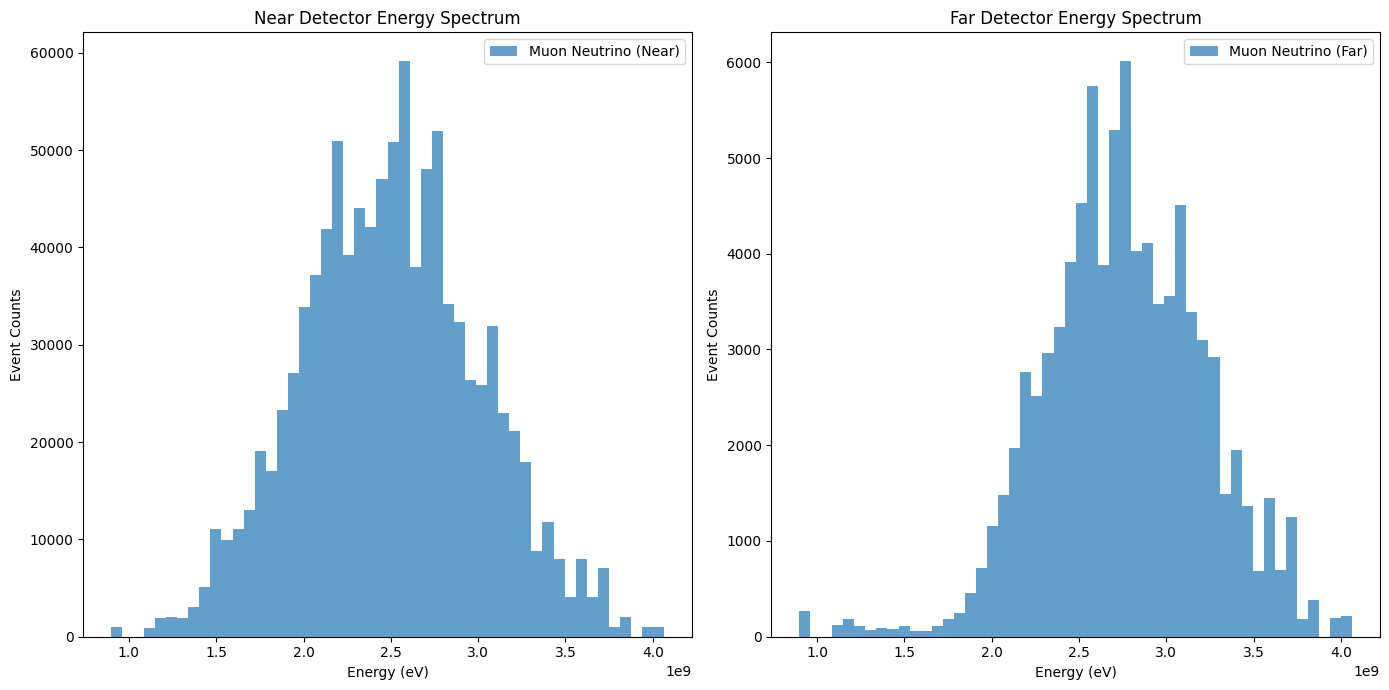

In [7]:
# Import libraries and functions
import numpy as np
import matplotlib.pyplot as plt
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *

# Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Define a Gaussian energy distribution
mean_energy = 2.5e9  # Mean energy in eV (corresponds to 2.5 GeV)
sigma_energy = 0.5e9  # Standard deviation in eV
energies = np.random.normal(mean_energy, sigma_energy, 1000)

# Initialize the vacuum Hamiltonian (energy-independent part)
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute probabilities with matter effects for a given baseline
def compute_probabilities_matter(baseline):
    Prob_e = []
    Prob_mu = []
    Prob_tau = []

    for E in energies:
        # Define matter Hamiltonian for each energy
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)

        # Calculate probabilities for this Hamiltonian and baseline
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_e.append(Pee)
        Prob_mu.append(Pmm)
        Prob_tau.append(Ptt)

    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute probabilities for near and far detectors
Prob_e_near, Prob_mu_near, Prob_tau_near = compute_probabilities_matter(Length_near)
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_matter(Length_far)

# Total number of events for near and far detectors
total_events_near = 1000
total_events_far = 300

# Generate Poisson-distributed event counts based on the probabilities
counts_e_near = np.random.poisson(lam=Prob_e_near * total_events_near)
counts_mu_near = np.random.poisson(lam=Prob_mu_near * total_events_near)
counts_tau_near = np.random.poisson(lam=Prob_tau_near * total_events_near)

counts_e_far = np.random.poisson(lam=Prob_e_far * total_events_far)
counts_mu_far = np.random.poisson(lam=Prob_mu_far * total_events_far)
counts_tau_far = np.random.poisson(lam=Prob_tau_far * total_events_far)

# Plot the histograms
plt.figure(figsize=(14, 7))

# Near detector
plt.subplot(1, 2, 1)
plt.hist(energies, bins=50, weights=counts_mu_near, label='Muon Neutrino (Near)', alpha=0.7)
plt.xlabel('Energy (eV)')
plt.ylabel('Event Counts')
plt.title('Near Detector Energy Spectrum')
plt.legend()

# Far detector
plt.subplot(1, 2, 2)
plt.hist(energies, bins=50, weights=counts_mu_far, label='Muon Neutrino (Far)', alpha=0.7)
plt.xlabel('Energy (eV)')
plt.ylabel('Event Counts')
plt.title('Far Detector Energy Spectrum')
plt.legend()

plt.tight_layout()
plt.show()
